In [1]:
import sys
import maboss
import pandas as pd
import numpy as np
sys.path.append("/Users/emilieyu/endotehelial-masboss")
import matplotlib.pyplot as plt

ipylab module is not installed, menus and toolbar are disabled.


In [ ]:
from src.config import load_sim_config, load_sweep_config, load_spatial_config
from src.paths import *
from boolean_models.scripts import run_perturbations, run_sweeps

sim_cfg = load_sim_config()
sweep_cfg = load_sweep_config()
spatial_cfg = load_spatial_config()

MODELS_BND = DATA_DIR / sim_cfg['model']['bnd_v2']
MODELS_CFG = DATA_DIR / sim_cfg['model']['cfg_v4']

from abm.flow_field import FlowField, get_mechanical_input
from abm.endothelial_cell import EndothelialCell
from abm.membrane_node import MembraneNode


## Recruitment Parameter Table

## Initiate ABM Classes

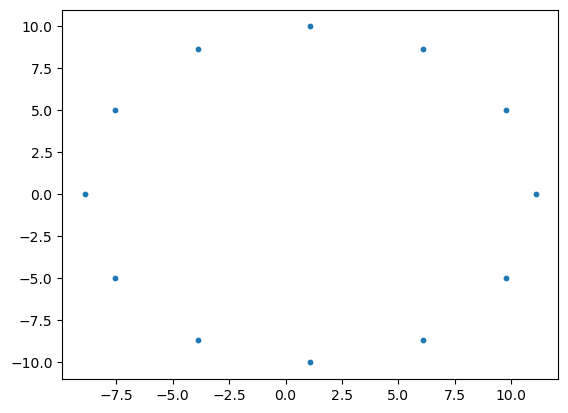

array([[ 1.11000000e+01,  0.00000000e+00],
       [ 9.76025404e+00,  5.00000000e+00],
       [ 6.10000000e+00,  8.66025404e+00],
       [ 1.10000000e+00,  1.00000000e+01],
       [-3.90000000e+00,  8.66025404e+00],
       [-7.56025404e+00,  5.00000000e+00],
       [-8.90000000e+00,  1.22464680e-15],
       [-7.56025404e+00, -5.00000000e+00],
       [-3.90000000e+00, -8.66025404e+00],
       [ 1.10000000e+00, -1.00000000e+01],
       [ 6.10000000e+00, -8.66025404e+00],
       [ 9.76025404e+00, -5.00000000e+00]])

In [6]:
cell = EndothelialCell(cell_id=1, centroid=np.array([1.1, 0.0]))
node1 = cell.positions[0]

plt.scatter(cell.positions[:,0], cell.positions[:,1], s=10)
plt.show()
plt.close()
cell.positions

In [10]:
field = FlowField()
faces, outward_normals = field.classify_faces(cell.positions)
faces, outward_normals 
n1 = outward_normals[1]
n1
direction = np.array([1.0, 0.0])

## Sigmoid Parameter Activation

In [6]:
def hill(tau, K, n):
    """
    S: Sensitivity input (sheae nmagnitude / force)
    K: Half activation thershold
    n: Hill coefficiet
    """
    return tau**n / (K**n + tau**n)

def get_protein_activation(cfg, tau, face_type, protein):
    hill_params = cfg['hill_params'][protein]
    face_biases = cfg['face_bias'][protein]

    K = hill_params['K']
    n = hill_params['n']
    bias = face_biases[face_type]

    # Effective shear felt by protein at specified face
    tau_eff = tau * bias

    return hill(tau_eff, K ,n)

def shear_to_boolean_states(cfg, tau, face_type):
    """
    Hill function gives probability of each protein being active. 
    Stochastically sampled to stay consistent with maboss philosophy. 

    - at low shear protein occasionally flips on
    - at threshold protein is on 50% of the time
    - at high shear protein is reliably on
    """
    
    p_dsp = get_protein_activation(cfg, tau, face_type, 'DSP')
    p_tjp1 = get_protein_activation(cfg, tau, face_type, 'TJP1')
    p_jcad = get_protein_activation(cfg, tau, face_type, 'JCAD')

     # Direct probabilistic sampling
    # This is now exactly what MaBoSS does internally with rate_up = p and rate_down = (1-p)
    dsp  = int(np.random.random() < p_dsp)
    tjp1 = int(np.random.random() < p_tjp1)
    jcad = int(np.random.random() < p_jcad)

    return dsp, tjp1, jcad